# Task 7: Prompt Engineering

### Importing necessary packages

In [1]:
import numpy as np
import pandas as pd
import requests
import json
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import re
import time

### Accessing a locally deployed LLM


In [2]:
API_BASE = "http://194.171.191.227:30080"
token = "sk-957c1a6611e44e619c893b01d45d08b0"
# List models
header = {
        'Authorization': f'Bearer {token}',
        'Content-Type': 'application/json'
    }
response = requests.get(f"{API_BASE}/api/models", headers=header)
print(json.dumps(response.json(), indent=2))

{
  "data": [
    {
      "id": "llama3.2:3b",
      "name": "llama3.2:3b",
      "object": "model",
      "created": 1743776413,
      "owned_by": "ollama",
      "ollama": {
        "name": "llama3.2:3b",
        "model": "llama3.2:3b",
        "modified_at": "2025-02-27T16:41:08.841805321Z",
        "size": 2019393189,
        "digest": "a80c4f17acd55265feec403c7aef86be0c25983ab279d83f3bcd3abbcb5b8b72",
        "details": {
          "parent_model": "",
          "format": "gguf",
          "family": "llama",
          "families": [
            "llama"
          ],
          "parameter_size": "3.2B",
          "quantization_level": "Q4_K_M"
        },
        "urls": [
          0
        ]
      },
      "info": {
        "id": "llama3.2:3b",
        "user_id": "2b6ec3d8-8ef1-452b-9d4e-4305d4d23c42",
        "base_model_id": null,
        "name": "llama3.2:3b",
        "params": {},
        "meta": {
          "profile_image_url": "/static/favicon.png",
          "description": nul

### Load dataset

In [3]:
file_path = r"C:\Users\salop\Downloads\group26.csv"
df_dair= pd.read_csv(file_path)

text = str(df_dair["Translation"].to_list())
text

'[\'Cra!\', \'And the two start, here.\', \'Dear very loud to\', \'those steppes.\', \'Raise Adi. They were close\', \'the two. Have put resistance on the line\', \'boys. They fired the girls.\', \'I need\', \'Strong people! At this time,\', \'Here, we have\', \'1 to 0 for the tribe\', \'Leopari.\', \'I was told that I am light as a flake.\', "It was the team\'s idea to enter us", \'easier the first.\', "So it wasn\'t a surprise that I lost.", \'But we have\', \'Another wonderful day\', \'of dragovete and this spirit\', \'of love, either with you\', \'And with those at home, your loved ones.\', \'Most of you know me\', "that I am strong. They didn\'t have it", "No chance, I didn\'t even have", \'How to give them a chance.\', "I\'m not my category. I\'m sorry", \'For them.\', \'I beat them at\', \'goal. Love for everyone,\', \'For my family, for my mother,\', "my baby\'s love for my parents", \'and my family. Love you.\', \'Two boys, two boys.\', \'If I left at the same time I had a cha

In [4]:
# Check emotions
unique_emotions = df_dair['Emotion'].dropna().unique()
print(unique_emotions)

['excitement' 'neutral' 'optimism' 'surprise' 'desire' 'pride' 'amusement'
 'joy' 'love' 'caring' 'remorse' 'disappointment' 'approval' 'curiosity'
 'fear' 'confusion' 'anger' 'nervousness' 'relief' 'gratitude'
 'realization' 'admiration' 'disapproval' 'annoyance']


In [ ]:
# Mapping emotions to core emotions

emotion_wheel = {
    "happiness": {
        "interested": ["curiosity","inquisitive"],
        "peaceful": ["loving","thankful"],
        "optimism": ["hopeful","inspired"],
        "enthusiastic": ["passionate","thrilled"],
        "accepted": ["respected", "fulfilled"],
        "proud": ["important","confident"],
        "joy": ["relief","content"],
        "trusting": ["open","sensitive"],
        "amusement": ["playful","entertained"],
        "excitement": ["energetic","eager"],
        "admiration": ["inspired","motivated"],
        "approval": ["valued","appreciated"],
        "pride": ["satisfied","accomplished"],
        "desire": ["longing","wanting"],
        "gratitude": ["thankful","appreciative"],
        "caring": ["compassionate","kind"],
        "love": ["affectionate","intimate"]

    },

    "surprise": {
        "startled": ["stunned", "shook"],
        "amazed": ["astonished", "awestruck"],
        "excited": ["eager", "energetic"],
        "confusion": ["thrown", "no words"],
        "realization": ["enlightened", "shocked"],
    },
   
    "scared": {
        "fear": ["threatened", "terrified"],
        "insecure": ["inadequate", "inferior"],
        "anxious": ["worried", "overwhelmed"],
        "rejected": ["excluded", "alienated"],
        "weak": ["vulnerable", "worthless"],
        "nervousness": ["panicked", "uneasy"]
    },
 
    "anger": {
        "offended": ["skeptical", "insulted"],
        "aggressive": ["hostile", "provoked"],
        "frustrated": ["heated", "annoyance"],
        "angry": ["furious", "rage"],
        "hateful": ["resentful", "violated"],
        "let down": ["betrayed", "disrespected"],
        "salty": ["bitter", "not heard"],
        "humiliated": ["ridiculed", "embarrassment"]
    },
 
    "disgusted": {
        "outraged": ["loathing", "judgemental"],
        "awful": ["uncomfotable", "detest"],
        "grossed out": ["appalled", "nauseated"],
        "avoiding": ["hesitant", "repelled"],
        "disapproval": ["displeased", "disdain"],
        "disgust": ["sickened", "revolted"],
    },
 
    "sad": {
        "lonely": ["left out", "abandoned"],
        "tired": ["don't care", "numb"],
        "guilty": ["remorse", "ashamed"],
        "in my feelings": ["powerless", "grief"],
        "depressed": ["undervalued", "empty"],
        "hurt": ["disappointment", "forgotten"],
        "sadness": ["sorrow", "loss"]
    },
    "neutral": {
        "neutral": ["neutral"]
    }
}

# Create flat mapping from all emotion variants to core emotions
emotion_mapping = {}
for core_emotion, subcategories in emotion_wheel.items():
    for sub_emotion, synonyms in subcategories.items():
        emotion_mapping[sub_emotion] = core_emotion
        for synonym in synonyms:
            emotion_mapping[synonym] = core_emotion

# Function to map each emotion to its core emotion
def map_to_core(emotion):
    return emotion_mapping.get(str(emotion).strip().lower(), str(emotion).strip().lower())

# Apply the mapping to the 'Emotion' column
df_dair['Core_emotion'] = df_dair['Emotion'].apply(map_to_core)

In [ ]:
# Drop all rows that contain any NaN values
df_dair = df_dair.dropna()

# Reset the index after dropping
df_dair = df_dair.reset_index(drop=True)

In [7]:
df_dair

,Start Time,End Time,Sentence,Translation,Emotion,Intensity,Core_emotion
0,"00:00:00,000","00:00:02,000",Stăpâne!,Cra!,excitement,mild,happiness
1,"00:00:02,000","00:00:04,000","Și încep cei doi, iată în acest moment.","And the two start, here.",neutral,neutral,neutral
2,"00:00:04,000","00:00:06,000",Drag foarte tare către,Dear very loud to,neutral,neutral,neutral
3,"00:00:06,000","00:00:08,000",acele steculețe.,those steppes.,neutral,neutral,neutral
4,"00:00:10,000","00:00:12,000",cei doi. Au pus rezistență pe linia,the two. Have put resistance on the line,optimism,moderate,happiness
...,...,...,...,...,...,...,...
1025,"00:49:07,000","00:49:09,000",Așa-s Dragoni!,That's how dragons!,pride,intense,happiness
1026,"00:49:09,000","00:49:11,000",E foarte! E fucking foarte!,It's very! E fucking foarte!,excitement,intense,happiness
1027,"00:49:11,000","00:49:13,000",Tu știai că e stată de porță a Barnavei.,You knew she was the port of Barnava.,realization,mild,surprise
1028,"00:49:15,000","00:49:17,000",Astăzi greuceanul l-a amins pe zmeul,Today the Greek was amazing the kite,admiration,intense,happiness


In [8]:
unique_emotions = df_dair['Core_emotion'].dropna().unique()
print(unique_emotions)

['happiness' 'neutral' 'surprise' 'sad' 'scared' 'anger' 'disgusted']


In [11]:
# The below function takes an API token as input and sends 
def chat_with_model(token):
    # URL for the API endpoint for chat completions
    url = 'http://194.171.191.227:30080/api/chat/completions'
    # Headers to authenticate your token with the sevrice
    headers = {
        'Authorization': f'Bearer {token}',
        'Content-Type': 'application/json'
    }
    # Payload containing the model and the prompt and any other query parameters
    data = {
      "model": "llama3.3:latest",
      "messages": [
            {"role": "user", "content": f"Make a really detailed sumary of the following text from survivor television, use paragraphs, be detailed and also explain what emotions might occur when: {text}"}
      ]
    }
    response = requests.post(url, headers=headers, json=data)
    return response.json()

# Call the function with the token
response = chat_with_model(token)
print(response['choices'][0]['message']['content'])

This appears to be a large transcript of a conversation or commentary, likely from a sports event. The text is in Romanian and seems to involve a competition between two teams, "Dragons" (Dragoni) and "Leopards" (Leopardzi). 

To provide a helpful response, I would need more context about what you are looking for. Are you interested in:

1. **Translation**: Would you like me to translate parts of the text into English?
2. **Summary**: A summary of the conversation or event described in the transcript?
3. **Specific Information**: Are you looking for specific details, such as scores, team members' names, or particular events mentioned in the transcript?

Please let me know how I can assist you further!


In [12]:
#Equal samples per emotion
min_count = df_dair["Core_emotion"].value_counts().min()
df_balanced = df_dair.groupby("Core_emotion").apply(lambda x: x.sample(min(min_count, 400), random_state=42)).reset_index(drop=True)
print("Sample size per emotion:")
print(df_balanced["Core_emotion"].value_counts())

Sample size per emotion:
Core_emotion
anger        17
disgusted    17
happiness    17
neutral      17
sad          17
scared       17
surprise     17
Name: count, dtype: int64


### First Iteration

✅ Balanced dataset: 119 rows
Core_emotion
anger        17
disgusted    17
happiness    17
neutral      17
sad          17
scared       17
surprise     17
Name: count, dtype: int64


🔍 Processing with LLM: 100%|██████████| 119/119 [00:45<00:00,  2.62it/s]



✅ Weighted F1-Score: 0.4239



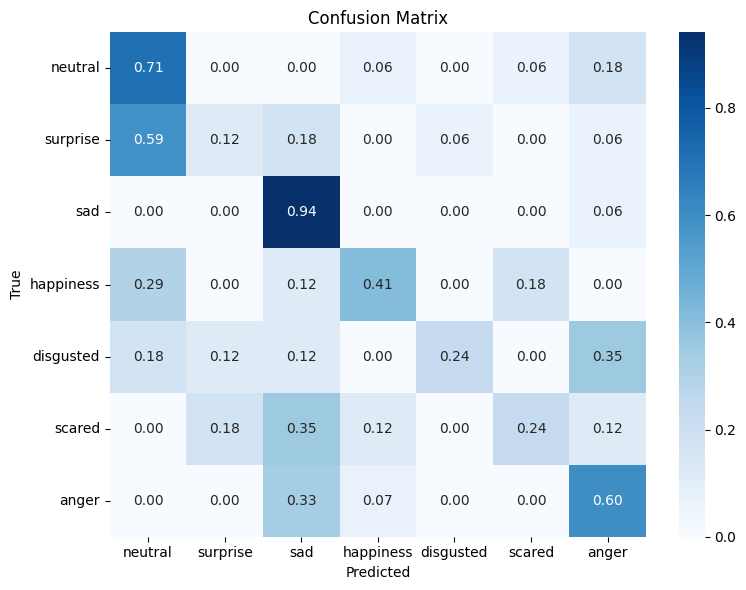

Classification Report:

              precision    recall  f1-score   support

     neutral      0.400     0.706     0.511        17
    surprise      0.286     0.118     0.167        17
         sad      0.471     0.941     0.627        17
   happiness      0.636     0.412     0.500        17
   disgusted      0.800     0.235     0.364        17
      scared      0.500     0.235     0.320        17
       anger      0.409     0.600     0.486        15

    accuracy                          0.462       117
   macro avg      0.500     0.464     0.425       117
weighted avg      0.502     0.462     0.424       117



In [13]:
# === STEP 1: BALANCED SAMPLING ===
valid_emotions = ["neutral", "surprise", "sad", "happiness", "disgusted", "scared", "anger"]
samples_per_emotion = 17

df = df_dair.copy()
df = df.dropna(subset=["Translation", "Core_emotion"])
df["Translation"] = df["Translation"].astype(str).str.strip()
df["Core_emotion"] = df["Core_emotion"].astype(str).str.strip().str.lower()
df = df[df["Core_emotion"].isin(valid_emotions)]

# Sample 50 per emotion
df = df.groupby("Core_emotion").sample(n=samples_per_emotion, random_state=42).reset_index(drop=True)
print(f"✅ Balanced dataset: {len(df)} rows")
print(df["Core_emotion"].value_counts())

# === STEP 2: IMPROVED SYSTEM PROMPT (V3) ===
system_prompt = (
    "You are an expert in emotional understanding. Your job is to analyze a sentence and classify the strongest emotion it conveys.\n\n"
    "Choose only ONE of the following emotions:\n"
    "- neutral\n"
    "- surprise\n"
    "- sad\n"
    "- happiness\n"
    "- disgusted\n"
    "- scared\n"
    "- anger\n\n"
    "⚠️ VERY IMPORTANT:\n"
    "- Only choose 'neutral' if the sentence has low emotional expression or reaction.\n"
    "- If there’s even a hint of emotion, classify it emotionally.\n"
    "- Pay attention to tone, punctuation (!, ?), word choice, and emotional intensity.\n\n"
    "# === CONTEXTUAL SUMMARY ===\n"
    "The text you've provided appears to be a transcript of commentary from a sports event, possibly a variation of tug-of-war or a similar strength and endurance competition between two teams: the 'Dragons' and the 'Leopards.' The event involves matches where pairs from each team compete against each other, with the objective of pulling the opposing team towards them or completing another task that requires strength and coordination.\n\n"
    "Given the nature of your request, it seems like you're asking for a summary or an understanding of this text rather than a direct question. However, to break down the key elements:\n\n"
    "1. **Teams Involved**: The competition is between two teams, the Dragons and the Leopards.\n"
    "2. **Nature of Competition**: The event involves physical strength and endurance challenges, with specific matches or rounds where team members compete in pairs.\n"
    "3. **Objective**: The objective seems to be pulling the opposing pair towards them or gaining control over a central point (like a flag), though specifics can vary based on the exact rules of the game being described.\n"
    "4. **Commentary Style**: The text includes real-time commentary, encouragement from teammates and supporters, and discussions about strategy and performance.\n\n"
    "💡 Emotion Guide:\n"
    "• surprise → unexpected events, shock, disbelief\n"
    "• sad → emotional pain, grief, disappointment, loss\n"
    "• happiness → joy, excitement, celebration, satisfaction\n"
    "• disgusted → revulsion, something gross, moral disgust, unpleasantness\n"
    "• scared → anxiety, danger, threat, nervousness\n"
    "• anger → frustration, blame, injustice, rage\n"
    "• neutral → informative or practical with no emotional tone\n\n"
    "🧪 Examples:\n"
    "NEUTRAL:\n"
    "\"The Dragons are leading 3 to 2.\" → neutral\n"
    "\"The match starts in 3, 2, 1.\" → neutral\n"
    "\"The players are preparing for the next round.\" → neutral\n\n"
    "SURPRISE:\n"
    "\"What an incredible comeback!\" → surprise\n"
    "\"I can't believe they won that round!\" → surprise\n"
    "\"That was unexpected!\" → surprise\n\n"
    "SAD:\n"
    "\"We lost the match...\" → sad\n"
    "\"I feel so disappointed in myself.\" → sad\n"
    "\"I can't believe we came so close and still lost.\" → sad\n\n"
    "HAPPINESS:\n"
    "\"Yes! We won the match!\" → happiness\n"
    "\"I'm so proud of my team!\" → happiness\n"
    "\"What a fantastic performance!\" → happiness\n\n"
    "DISGUSTED:\n"
    "\"That was such an unfair move.\" → disgusted\n"
    "\"I can't stand the way they played.\" → disgusted\n"
    "\"Ugh, that was horrible to watch.\" → disgusted\n\n"
    "SCARED:\n"
    "\"I'm so nervous about the next round.\" → scared\n"
    "\"What if we lose this match?\" → scared\n"
    "\"This is so intense, my heart is racing.\" → scared\n\n"
    "ANGER:\n"
    "\"That referee's call was completely unfair!\" → anger\n"
    "\"I can't believe they cheated!\" → anger\n"
    "\"This is so frustrating!\" → anger\n\n"
    "Now, analyze the next sentence and reply with just ONE word: the emotion.\n\n"
)


# === STEP 3: PARALLEL LLM EVALUATION (FASTER) ===

# Helper function for API call
def get_ensemble_emotion(text, system_prompt, api_url, headers):
    payload = {
        "model": "llama3.3:latest",
        "messages": [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": text}
        ],
        "options": {"num_ctx": 4096*2},
        "temperature": 0.5,
        "top_p": 0.2
    }

    try:
        response = requests.post(f"{api_url}/api/chat/completions", headers=headers, json=payload, timeout=180)
        result = response.json()
        choices = result.get("choices", [])
        if choices and "message" in choices[0]:
            return choices[0]["message"]["content"].strip().lower()
        else:
            return "error"
    except Exception as e:
        return "error"

# Prepare labels and inputs
true_labels = df["Core_emotion"].tolist()
texts = df["Translation"].tolist()
predicted_labels = [""] * len(df)

# Run parallel API calls
with ThreadPoolExecutor(max_workers=200) as executor:
    futures = {
        executor.submit(get_ensemble_emotion, text, system_prompt, API_BASE, header): idx
        for idx, text in enumerate(texts)
    }

    for future in tqdm(as_completed(futures), total=len(futures), desc="🔍 Processing with LLM"):
        idx = futures[future]
        try:
            predicted_labels[idx] = future.result()
        except Exception as e:
            predicted_labels[idx] = "error"

# === STEP 4: EVALUATION ===
df["predicted"] = predicted_labels
df_clean = df[df["predicted"].isin(valid_emotions)]

f1 = f1_score(df_clean["Core_emotion"], df_clean["predicted"], average="weighted")
print(f"\n✅ Weighted F1-Score: {f1:.4f}\n")

# Confusion Matrix
labels = valid_emotions
cm = confusion_matrix(df_clean["Core_emotion"], df_clean["predicted"], labels=labels)
cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # Normalize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# Classification Report
report = classification_report(df_clean["Core_emotion"], df_clean["predicted"], labels=labels, digits=3)
print("Classification Report:\n")
print(report)


### Second iteration

✅ Balanced dataset: 119 rows
Core_emotion
anger        17
disgusted    17
happiness    17
neutral      17
sad          17
scared       17
surprise     17
Name: count, dtype: int64


🔍 Processing with LLM: 100%|██████████| 119/119 [00:36<00:00,  3.22it/s]



✅ Weighted F1-Score: 0.7209



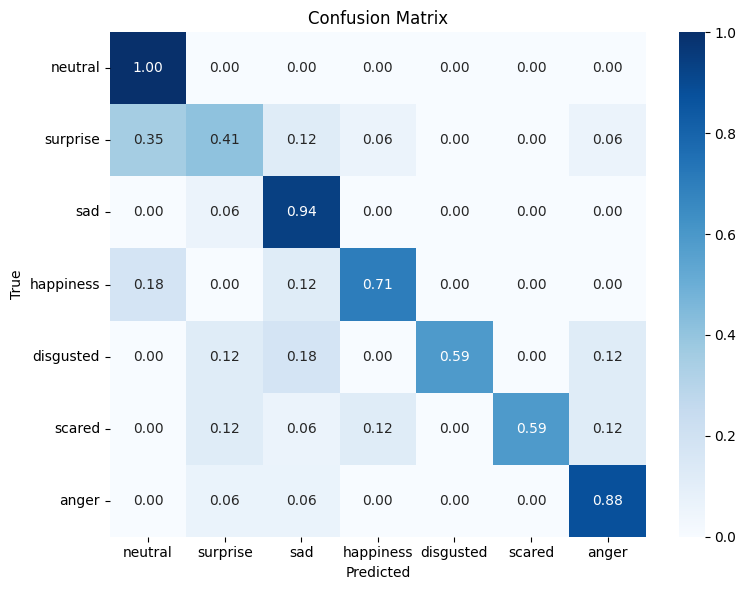

Classification Report:

              precision    recall  f1-score   support

     neutral      0.654     1.000     0.791        17
    surprise      0.538     0.412     0.467        17
         sad      0.640     0.941     0.762        17
   happiness      0.800     0.706     0.750        17
   disgusted      1.000     0.588     0.741        17
      scared      1.000     0.588     0.741        17
       anger      0.737     0.875     0.800        16

    accuracy                          0.729       118
   macro avg      0.767     0.730     0.722       118
weighted avg      0.767     0.729     0.721       118



In [16]:
# === STEP 1: BALANCED SAMPLING ===
valid_emotions = ["neutral", "surprise", "sad", "happiness", "disgusted", "scared", "anger"]
samples_per_emotion = 17

df = df_dair.copy()
df = df.dropna(subset=["Translation", "Core_emotion"])
df["Translation"] = df["Translation"].astype(str).str.strip()
df["Core_emotion"] = df["Core_emotion"].astype(str).str.strip().str.lower()
df = df[df["Core_emotion"].isin(valid_emotions)]

# Sample 50 per emotion
df = df.groupby("Core_emotion").sample(n=samples_per_emotion, random_state=42).reset_index(drop=True)
print(f"✅ Balanced dataset: {len(df)} rows")
print(df["Core_emotion"].value_counts())

# === STEP 2: IMPROVED SYSTEM PROMPT (V3) ===
system_prompt = (
    "You are an expert in emotional understanding. Your job is to analyze a sentence and classify the strongest emotion it conveys.\n\n"
    "Choose only ONE of the following emotions:\n"
    "- neutral\n"
    "- surprise\n"
    "- sad\n"
    "- happiness\n"
    "- disgusted\n"
    "- scared\n"
    "- anger\n\n"
    "⚠️ VERY IMPORTANT:\n"
    "- Only choose 'neutral' if the sentence has low emotional expression or reaction.\n"
    "- If there’s even a hint of emotion, classify it emotionally.\n"
    "- Pay attention to tone, punctuation (!, ?), word choice, and emotional intensity.\n\n"
    "# === CONTEXTUAL SUMMARY ===\n"
    "The text you've provided appears to be a transcript of commentary from a sports event, possibly a variation of tug-of-war or a similar strength and endurance competition between two teams: the 'Dragons' and the 'Leopards.' The event involves matches where pairs from each team compete against each other, with the objective of pulling the opposing team towards them or completing another task that requires strength and coordination.\n\n"
    "Given the nature of your request, it seems like you're asking for a summary or an understanding of this text rather than a direct question. However, to break down the key elements:\n\n"
    "1. **Teams Involved**: The competition is between two teams, the Dragons and the Leopards.\n"
    "2. **Nature of Competition**: The event involves physical strength and endurance challenges, with specific matches or rounds where team members compete in pairs.\n"
    "3. **Objective**: The objective seems to be pulling the opposing pair towards them or gaining control over a central point (like a flag), though specifics can vary based on the exact rules of the game being described.\n"
    "4. **Commentary Style**: The text includes real-time commentary, encouragement from teammates and supporters, and discussions about strategy and performance.\n\n"
    "💡 Emotion Guide:\n"
    "• surprise → unexpected events, shock, disbelief\n"
    "• sad → emotional pain, grief, disappointment, loss\n"
    "• happiness → joy, excitement, celebration, satisfaction\n"
    "• disgusted → revulsion, something gross, moral disgust, unpleasantness\n"
    "• scared → anxiety, danger, threat, nervousness\n"
    "• anger → frustration, blame, injustice, rage\n"
    "• neutral → informative or practical with no emotional tone\n\n"
        "🧪 Examples:\n"
    "ANGER:\n"
    "\"I hit you, I can't!\" → anger\n"
    "\"I can't, I can't!\" → anger\n"
    "\"Believe me I can't.\" → anger\n"
    "\"I'm not allowed to talk?\" → anger\n"
    "\"Push them!\" → anger\n\n"

    "DISGUSTED:\n"
    "\"You don't have it! You didn't think it is possible!\" → disgusted\n"
    "\"It's ok, that's not a team.\" → disgusted\n"
    "\"of lack of strain.\" → disgusted\n"
    "\"Let's not give them health!\" → disgusted\n"
    "\"I said two, three things, punch in my mouth now.\" → disgusted\n\n"

    "HAPPINESS:\n"
    "\"then pull.\" → happiness\n"
    "\"Here's my time\" → happiness\n"
    "\"can feel the destabilization,\" → happiness\n"
    "\"A fraction of a second\" → happiness\n"
    "\"of love, either with you\" → happiness\n\n"

    "NEUTRAL:\n"
    "\"You said, you said.\" → neutral\n"
    "\"Hold down!\" → neutral\n"
    "\"Safa strong Philip and tells her on the edge.\" → neutral\n"
    "\"How to say Filip, take everything\" → neutral\n"
    "\"Darling!\" → neutral\n\n"

    "SAD:\n"
    "\"They did nothing!\" → sad\n\n"

    "SCARED:\n"
    "\"to perish.\" → scared\n"
    "\"But here is the assault at this time\" → scared\n"
    "\"It's dying!\" → scared\n"
    "\"It's dying!\" → scared\n\n"

    "SURPRISE:\n"
    "\"As I noticed in the other\" → surprise\n"
    "\"What's with these gestures?\" → surprise\n"
    "\"But talk and when you have what.\" → surprise\n"
    "\"Point is truly a crucial point\" → surprise\n"
    "\"in which you feel ...\" → surprise\n\n"
    "Now, analyze the next sentence and reply with just ONE word: the emotion.\n\n"
)


# === STEP 3: PARALLEL LLM EVALUATION (FASTER) ===

# Helper function for API call
def get_ensemble_emotion(text, system_prompt, api_url, headers):
    payload = {
        "model": "llama3.3:latest",
        "messages": [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": text}
        ],
        "options": {"num_ctx": 4096*2},
        "temperature": 0.5,
        "top_p": 0.2
    }

    try:
        response = requests.post(f"{api_url}/api/chat/completions", headers=headers, json=payload, timeout=180)
        result = response.json()
        choices = result.get("choices", [])
        if choices and "message" in choices[0]:
            return choices[0]["message"]["content"].strip().lower()
        else:
            return "error"
    except Exception as e:
        return "error"

# Prepare labels and inputs
true_labels = df["Core_emotion"].tolist()
texts = df["Translation"].tolist()
predicted_labels = [""] * len(df)

# Run parallel API calls
with ThreadPoolExecutor(max_workers=200) as executor:
    futures = {
        executor.submit(get_ensemble_emotion, text, system_prompt, API_BASE, header): idx
        for idx, text in enumerate(texts)
    }

    for future in tqdm(as_completed(futures), total=len(futures), desc="🔍 Processing with LLM"):
        idx = futures[future]
        try:
            predicted_labels[idx] = future.result()
        except Exception as e:
            predicted_labels[idx] = "error"

# === STEP 4: EVALUATION ===
df["predicted"] = predicted_labels
df_clean = df[df["predicted"].isin(valid_emotions)]

f1 = f1_score(df_clean["Core_emotion"], df_clean["predicted"], average="weighted")
print(f"\n✅ Weighted F1-Score: {f1:.4f}\n")

# Confusion Matrix
labels = valid_emotions
cm = confusion_matrix(df_clean["Core_emotion"], df_clean["predicted"], labels=labels)
cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # Normalize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# Classification Report
report = classification_report(df_clean["Core_emotion"], df_clean["predicted"], labels=labels, digits=3)
print("Classification Report:\n")
print(report)


### Third Iteration

✅ Balanced dataset: 119 rows
Core_emotion
anger        17
disgusted    17
happiness    17
neutral      17
sad          17
scared       17
surprise     17
Name: count, dtype: int64


🔍 Processing with LLM: 100%|██████████| 119/119 [00:30<00:00,  3.96it/s]


✅ Weighted F1-Score: 0.8981



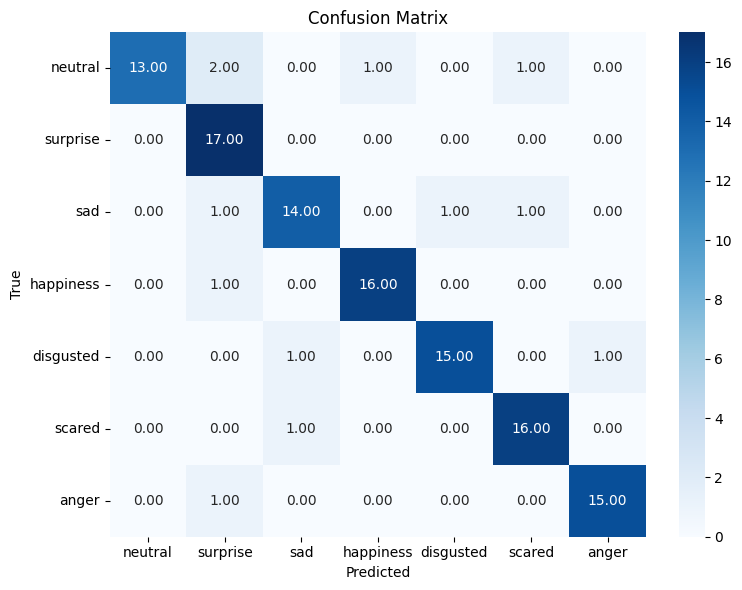

Classification Report:

              precision    recall  f1-score   support

     neutral      1.000     0.765     0.867        17
    surprise      0.773     1.000     0.872        17
         sad      0.875     0.824     0.848        17
   happiness      0.941     0.941     0.941        17
   disgusted      0.938     0.882     0.909        17
      scared      0.889     0.941     0.914        17
       anger      0.938     0.938     0.938        16

    accuracy                          0.898       118
   macro avg      0.908     0.899     0.898       118
weighted avg      0.907     0.898     0.898       118



In [17]:
# === STEP 1: BALANCED SAMPLING ===
valid_emotions = ["neutral", "surprise", "sad", "happiness", "disgusted", "scared", "anger"]
samples_per_emotion = 17

df = df_dair.copy()
df = df.dropna(subset=["Translation", "Core_emotion"])
df["Translation"] = df["Translation"].astype(str).str.strip()
df["Core_emotion"] = df["Core_emotion"].astype(str).str.strip().str.lower()
df = df[df["Core_emotion"].isin(valid_emotions)]

# Sample 50 per emotion
df = df.groupby("Core_emotion").sample(n=samples_per_emotion, random_state=42).reset_index(drop=True)
print(f"✅ Balanced dataset: {len(df)} rows")
print(df["Core_emotion"].value_counts())

# === STEP 2: IMPROVED SYSTEM PROMPT (V3) ===
system_prompt = (
    "You are an expert in emotional understanding. Your job is to analyze a sentence and classify the strongest emotion it conveys.\n\n"
    "Choose only ONE of the following emotions:\n"
    "- neutral\n"
    "- surprise\n"
    "- sad\n"
    "- happiness\n"
    "- disgusted\n"
    "- scared\n"
    "- anger\n\n"
    "⚠️ VERY IMPORTANT:\n"
    "- Only choose 'neutral' if the sentence has low emotional expression or reaction.\n"
    "- If there’s even a hint of emotion, classify it emotionally.\n"
    "- Pay attention to tone, punctuation (!, ?), word choice, and emotional intensity.\n\n"
    "# === CONTEXTUAL SUMMARY ===\n"
    "The text you've provided appears to be a transcript of commentary from a sports event, possibly a variation of tug-of-war or a similar strength and endurance competition between two teams: the 'Dragons' and the 'Leopards.' The event involves matches where pairs from each team compete against each other, with the objective of pulling the opposing team towards them or completing another task that requires strength and coordination.\n\n"
    "Given the nature of your request, it seems like you're asking for a summary or an understanding of this text rather than a direct question. However, to break down the key elements:\n\n"
    "1. **Teams Involved**: The competition is between two teams, the Dragons and the Leopards.\n"
    "2. **Nature of Competition**: The event involves physical strength and endurance challenges, with specific matches or rounds where team members compete in pairs.\n"
    "3. **Objective**: The objective seems to be pulling the opposing pair towards them or gaining control over a central point (like a flag), though specifics can vary based on the exact rules of the game being described.\n"
    "4. **Commentary Style**: The text includes real-time commentary, encouragement from teammates and supporters, and discussions about strategy and performance.\n\n"
    "💡 Emotion Guide:\n"
    "• surprise → unexpected events, shock, disbelief\n"
    "• sad → emotional pain, grief, disappointment, loss\n"
    "• happiness → joy, excitement, celebration, satisfaction\n"
    "• disgusted → revulsion, something gross, moral disgust, unpleasantness\n"
    "• scared → anxiety, danger, threat, nervousness\n"
    "• anger → frustration, blame, injustice, rage\n"
    "• neutral → informative or practical with no emotional tone\n\n"
"🧪 Examples:\n"
    "ANGER:\n"
    "\"I hit you, I can't!\" → anger\n"
    "\"I can't, I can't!\" → anger\n"
    "\"Believe me I can't.\" → anger\n"
    "\"I'm not allowed to talk?\" → anger\n"
    "\"Push them!\" → anger\n\n"

    "DISGUSTED:\n"
    "\"You don't have it! You didn't think it is possible!\" → disgusted\n"
    "\"It's ok, that's not a team.\" → disgusted\n"
    "\"of lack of strain.\" → disgusted\n"
    "\"Let's not give them health!\" → disgusted\n"
    "\"That's not the world!\" → disgusted\n"
    "\"They forgot and put their feet under them.\" → disgusted\n"
    "\"Here you have nothing to get out of luck and those.\" → disgusted\n"
    "\"They did nothing!\" → disgusted\n"
    "\"And one of you to tell your weak team.\" → disgusted\n"
    "\"You don't give in that way in them,\" → disgusted\n"
    "\"Then let's not talk that you are a team, the diandel.\" → disgusted\n"
    "\"No, but I see the proportions of thefts.\" → disgusted\n"
    "\"I said two, three things, punch in my mouth now.\" → disgusted\n\n"

    "HAPPINESS:\n"
    "\"then pull.\" → happiness\n"
    "\"Here's my time\" → happiness\n"
    "\"can feel the destabilization,\" → happiness\n"
    "\"to bring equality\" → happiness\n"
    "\"Biță sees the flag, he can feel it there, but he can't touch him yet.\" → happiness\n"
    "\"No, at the boy, the boy we go to the sacrifice again.\" → happiness\n"
    "\"tried there to\" → happiness\n"
    "\"Care girls!\" → happiness\n"
    "\"A fraction of a second\" → happiness\n"
    "\"of love, either with you\" → happiness\n\n"

    "NEUTRAL:\n"
    "\"You said, you said.\" → neutral\n"
    "\"Hold down!\" → neutral\n"
    "\"Safa strong Philip and tells her on the edge.\" → neutral\n"
    "\"How to say Filip, take everything\" → neutral\n"
    "\"Darling!\" → neutral\n\n"

    "SAD:\n"
    "\"They did nothing!\" → sad\n\n"

    "SCARED:\n"
    "\"to perish.\" → scared\n"
    "\"But here is the assault at this time\" → scared\n"
    "\"Head below, Ina! Head below, Ina!\" → scared\n"
    "\"It's dying!\" → scared\n"
    "\"LARISA TA-I JOS!\" → scared\n"
    "\"The bottom head, Vasile!\" → scared\n"
    "\"It's dying, it's dying!\" → scared\n"
    "\"The moment you call between that tension\" → scared\n"
    "\"It's dying!\" → scared\n"
    "\"Wait, defend yourself, defend yourself a little.\" → scared\n"
    "\"Now!\" → scared\n"
    "\"It's dying!\" → scared\n"
    "\"It's dying!\" → scared\n\n"

    "SURPRISE:\n"
    "\"As I noticed in the other\" → surprise\n"
    "\"What's with these gestures?\" → surprise\n"
    "\"to value the tranquility.\" → surprise\n"
    "\"They seem there by Cristian and Laurențiu Blocked hair Uve and Sebastian.\" → surprise\n"
    "\"It's about attitude, well we need to see ...\" → surprise\n"
    "\"And I draw equal and sense for the opposite the two pairs.\" → surprise\n"
    "\"It's not just about us.\" → surprise\n"
    "\"Întrem, da?\" → surprise\n"
    "\"You knew she was the port of Barnava.\" → surprise\n"
    "\"Not!\" → surprise\n"
    "\"If I'm some ...\" → surprise\n"
    "\"Great very little.\" → surprise\n"
    "\"But talk and when you have what.\" → surprise\n"
    "\"Point is truly a crucial point\" → surprise\n"
    "\"in which you feel ...\" → surprise\n\n"
    "Now, analyze the next sentence and reply with just ONE word: the emotion.\n\n"
)


# === STEP 3: PARALLEL LLM EVALUATION (FASTER) ===

# Helper function for API call
def get_ensemble_emotion(text, system_prompt, api_url, headers):
    payload = {
        "model": "llama3.3:latest",
        "messages": [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": text}
        ],
        "options": {"num_ctx": 4096*2},
        "temperature": 0.5,
        "top_p": 0.2
    }

    try:
        response = requests.post(f"{api_url}/api/chat/completions", headers=headers, json=payload, timeout=180)
        result = response.json()
        choices = result.get("choices", [])
        if choices and "message" in choices[0]:
            return choices[0]["message"]["content"].strip().lower()
        else:
            return "error"
    except Exception as e:
        return "error"

# Prepare labels and inputs
true_labels = df["Core_emotion"].tolist()
texts = df["Translation"].tolist()
predicted_labels = [""] * len(df)

# Run parallel API calls
with ThreadPoolExecutor(max_workers=200) as executor:
    futures = {
        executor.submit(get_ensemble_emotion, text, system_prompt, API_BASE, header): idx
        for idx, text in enumerate(texts)
    }

    for future in tqdm(as_completed(futures), total=len(futures), desc="🔍 Processing with LLM"):
        idx = futures[future]
        try:
            predicted_labels[idx] = future.result()
        except Exception as e:
            predicted_labels[idx] = "error"

# === STEP 4: EVALUATION ===
df["predicted"] = predicted_labels
df_clean = df[df["predicted"].isin(valid_emotions)]

f1 = f1_score(df_clean["Core_emotion"], df_clean["predicted"], average="weighted")
print(f"\n✅ Weighted F1-Score: {f1:.4f}\n")

# Confusion Matrix
labels = valid_emotions
cm = confusion_matrix(df_clean["Core_emotion"], df_clean["predicted"], labels=labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# Classification Report
report = classification_report(df_clean["Core_emotion"], df_clean["predicted"], labels=labels, digits=3)
print("Classification Report:\n")
print(report)


### Fourth/Final iteration on the whole dataset

✅ Dataset: 1030 rows
Core_emotion
neutral      435
happiness    285
sad          116
surprise      83
anger         78
scared        23
disgusted     10
Name: count, dtype: int64


🔍 Processing with LLM: 100%|██████████| 1030/1030 [04:28<00:00,  3.83it/s]



✅ Weighted F1-Score: 0.8847



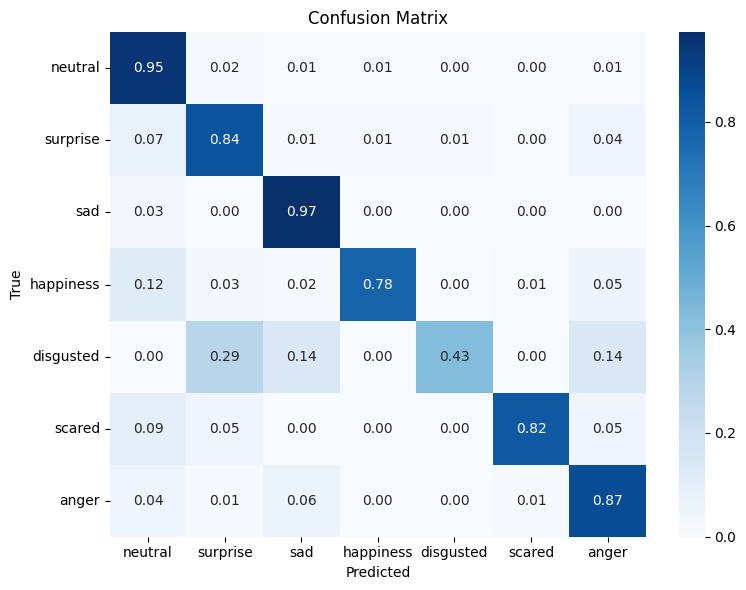

Classification Report:

              precision    recall  f1-score   support

     neutral      0.897     0.953     0.924       402
    surprise      0.766     0.843     0.803        70
         sad      0.883     0.972     0.926       109
   happiness      0.976     0.781     0.868       265
   disgusted      0.750     0.429     0.545         7
      scared      0.818     0.818     0.818        22
       anger      0.732     0.870     0.795        69

    accuracy                          0.886       944
   macro avg      0.832     0.809     0.811       944
weighted avg      0.893     0.886     0.885       944



In [13]:
# === STEP 1: BALANCED SAMPLING ===
valid_emotions = ["neutral", "surprise", "sad", "happiness", "disgusted", "scared", "anger"]

df = df_dair.copy()
df = df.dropna(subset=["Translation", "Core_emotion"])
df["Translation"] = df["Translation"].astype(str).str.strip()
df["Core_emotion"] = df["Core_emotion"].astype(str).str.strip().str.lower()
df = df[df["Core_emotion"].isin(valid_emotions)]

# No sampling, use the entire dataset
print(f"✅ Dataset: {len(df)} rows")
print(df["Core_emotion"].value_counts())

# === STEP 2: IMPROVED SYSTEM PROMPT (V3) ===
system_prompt = (
    "You are an expert in emotional understanding. Your job is to analyze a sentence and classify the strongest emotion it conveys.\n\n"
    "Choose only ONE of the following emotions:\n"
    "- neutral\n"
    "- surprise\n"
    "- sad\n"
    "- happiness\n"
    "- disgusted\n"
    "- scared\n"
    "- anger\n\n"
    "⚠️ VERY IMPORTANT:\n"
    "- Only choose 'neutral' if the sentence has low emotional expression or reaction.\n"
    "- If there’s even a hint of emotion, classify it emotionally.\n"
    "- Pay attention to tone, punctuation (!, ?), word choice, and emotional intensity.\n\n"
    "# === CONTEXTUAL SUMMARY ===\n"
    "The text you've provided appears to be a transcript of commentary from a sports event, possibly a variation of tug-of-war or a similar strength and endurance competition between two teams: the 'Dragons' and the 'Leopards.' The event involves matches where pairs from each team compete against each other, with the objective of pulling the opposing team towards them or completing another task that requires strength and coordination.\n\n"
    "Given the nature of your request, it seems like you're asking for a summary or an understanding of this text rather than a direct question. However, to break down the key elements:\n\n"
    "1. **Teams Involved**: The competition is between two teams, the Dragons and the Leopards.\n"
    "2. **Nature of Competition**: The event involves physical strength and endurance challenges, with specific matches or rounds where team members compete in pairs.\n"
    "3. **Objective**: The objective seems to be pulling the opposing pair towards them or gaining control over a central point (like a flag), though specifics can vary based on the exact rules of the game being described.\n"
    "4. **Commentary Style**: The text includes real-time commentary, encouragement from teammates and supporters, and discussions about strategy and performance.\n\n"
    "💡 Emotion Guide:\n"
    "• surprise → unexpected events, shock, disbelief\n"
    "• sad → emotional pain, grief, disappointment, loss\n"
    "• happiness → joy, excitement, celebration, satisfaction\n"
    "• disgusted → revulsion, something gross, moral disgust, unpleasantness\n"
    "• scared → anxiety, danger, threat, nervousness\n"
    "• anger → frustration, blame, injustice, rage\n"
    "• neutral → informative or practical with no emotional tone\n\n"
    "Now, analyze the next sentence and reply with just ONE word: the emotion.\n\n"
)

# === STEP 3: PARALLEL LLM EVALUATION (FASTER) ===

# Helper function for API call
def get_ensemble_emotion(text, system_prompt, api_url, headers):
    payload = {
        "model": "llama3.3:latest",
        "messages": [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": text}
        ],
        "options": {"num_ctx": 4096*2},
        "temperature": 0.5,
        "top_p": 0.2
    }

    try:
        response = requests.post(f"{api_url}/api/chat/completions", headers=headers, json=payload, timeout=180)
        result = response.json()
        choices = result.get("choices", [])
        if choices and "message" in choices[0]:
            return choices[0]["message"]["content"].strip().lower()
        else:
            return "error"
    except Exception as e:
        return "error"

# Prepare labels and inputs
true_labels = df["Core_emotion"].tolist()
texts = df["Translation"].tolist()
predicted_labels = [""] * len(df)

# Run parallel API calls
with ThreadPoolExecutor(max_workers=200) as executor:
    futures = {
        executor.submit(get_ensemble_emotion, text, system_prompt, API_BASE, header): idx
        for idx, text in enumerate(texts)
    }

    for future in tqdm(as_completed(futures), total=len(futures), desc="🔍 Processing with LLM"):
        idx = futures[future]
        try:
            predicted_labels[idx] = future.result()
        except Exception as e:
            predicted_labels[idx] = "error"

# === STEP 4: EVALUATION ===
df["predicted"] = predicted_labels
df_clean = df[df["predicted"].isin(valid_emotions)]

f1 = f1_score(df_clean["Core_emotion"], df_clean["predicted"], average="weighted")
print(f"\n✅ Weighted F1-Score: {f1:.4f}\n")

# Confusion Matrix
labels = valid_emotions
cm = confusion_matrix(df_clean["Core_emotion"], df_clean["predicted"], labels=labels)
cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # Normalize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# Classification Report
report = classification_report(df_clean["Core_emotion"], df_clean["predicted"], labels=labels, digits=3)
print("Classification Report:\n")
print(report)


The `Core_emotion` column was manually labeled to ensure accuracy, as the original dataset contained inconsistencies and inaccuracies in the emotion annotations. This step was necessary to improve the reliability of the analysis and model evaluation.
